C:\Users\teren\AppData\Local\Temp\ipykernel_13244\397988673.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['adopted'] = df['adopted'].fillna(False)
C:\Users\teren\AppData\Local\Temp\ipykernel_13244\397988673.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)['adopted']


Adopted: 2,248 / 12,000 (18.7%)

── Creation Source ──
                     rate  n_adopted  total
creation_source                            
GUEST_INVITE        23.2%        502   2163
SIGNUP_GOOGLE_AUTH  22.7%        314   1385
SIGNUP              20.0%        418   2087
ORG_INVITE          18.4%        783   4254
PERSONAL_PROJECTS   10.9%        231   2111

── Org Size ──
                  rate  n_adopted  total
org_size_bucket                         
6-10             24.8%         27    109
11-50            20.8%       1801   8639
50+              12.9%        420   3250
2-5               0.0%          0      2

── Invitation Context ──
              context  rate
          Not invited 17.2%
Invited (non-adopter) 18.9%
   Invited by adopter 23.9%

── Marketing Signals ──
                           rate  n_adopted  total
opted_in_to_mailing_list                         
1                         19.3%        578   2994
0                         18.5%       1670   9006
            

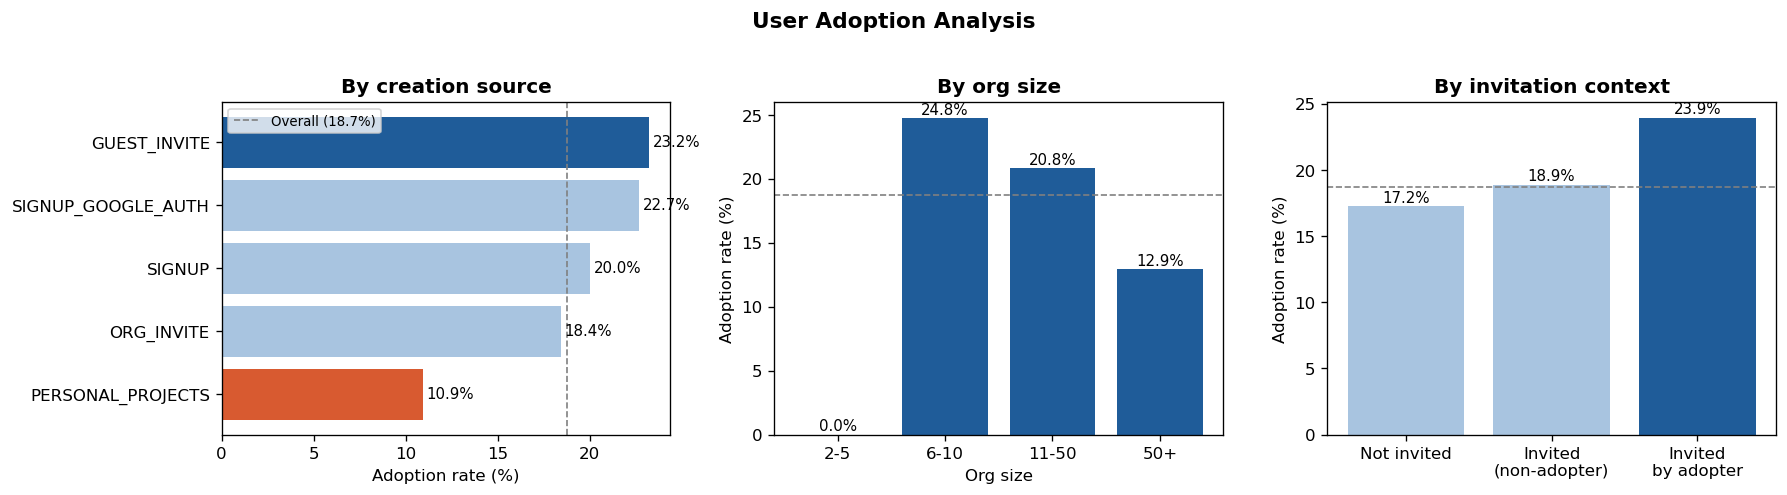

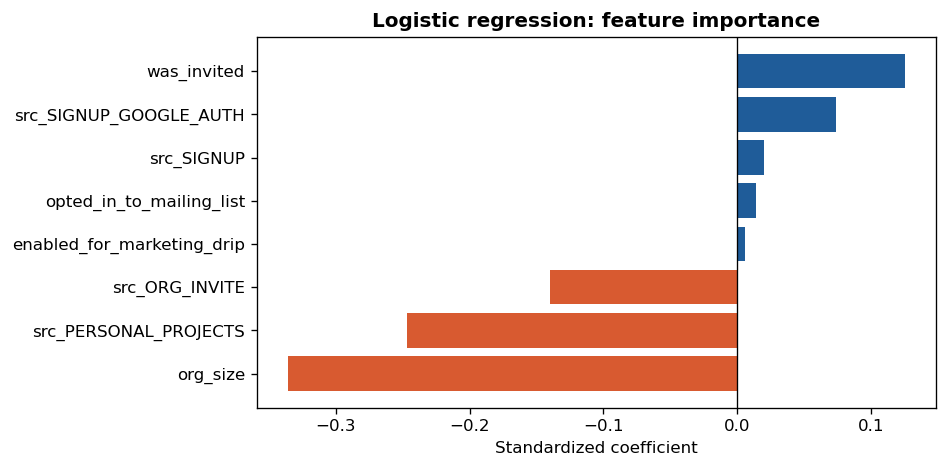

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# ── 1. Load Data ──────────────────────────────────────────────────────────────
DATA_DIR = r'C:\Users\teren\OneDrive\Documents\Education\05._SpringBoard\09. Interview Prep\02. Relax Challenge'

users = pd.read_csv(f'{DATA_DIR}\\takehome_users.csv', encoding='latin-1')
eng   = pd.read_csv(f'{DATA_DIR}\\takehome_user_engagement.csv', encoding='latin-1')

# ── 2. Define Adopted Users ───────────────────────────────────────────────────
# Adopted = 3+ distinct login days within any 7-day window

eng['time_stamp'] = pd.to_datetime(eng['time_stamp'])

def is_adopted(logins):
    dates = sorted(logins.dt.normalize().unique())
    if len(dates) < 3:
        return False
    for d in dates:
        if sum(x <= d + pd.Timedelta(days=6) for x in dates) >= 3:
            return True
    return False

adopted_flags = (
    eng.sort_values(['user_id', 'time_stamp'])
    .groupby('user_id')['time_stamp']
    .apply(is_adopted)
    .reset_index()
    .rename(columns={'time_stamp': 'adopted'})
)

df = users.merge(adopted_flags, left_on='object_id', right_on='user_id', how='left')
df['adopted'] = df['adopted'].fillna(False)

rate = df['adopted'].mean()
print(f"Adopted: {df['adopted'].sum():,} / {len(df):,} ({rate:.1%})")

# ── 3. Feature Engineering ────────────────────────────────────────────────────
org_sizes = df.groupby('org_id').size().reset_index(name='org_size')
df = df.merge(org_sizes, on='org_id', how='left')

df['was_invited'] = df['invited_by_user_id'].notna()

adopter_ids = set(df.loc[df['adopted'], 'object_id'])
df['invited_by_adopter'] = df['invited_by_user_id'].apply(
    lambda x: (x in adopter_ids) if pd.notna(x) else None
)

df['org_size_bucket'] = pd.cut(
    df['org_size'], bins=[0, 5, 10, 50, 10000], labels=['2-5', '6-10', '11-50', '50+']
)

# ── 4. Factor Analysis ────────────────────────────────────────────────────────
def adoption_table(df, col):
    return (
        df.groupby(col)['adopted']
        .agg(rate='mean', n_adopted='sum', total='count')
        .sort_values('rate', ascending=False)
        .assign(rate=lambda x: x['rate'].map('{:.1%}'.format))
    )

print("\n── Creation Source ──")
print(adoption_table(df, 'creation_source').to_string())

print("\n── Org Size ──")
print(adoption_table(df, 'org_size_bucket').to_string())

print("\n── Invitation Context ──")
inv = pd.DataFrame({
    'context': ['Not invited', 'Invited (non-adopter)', 'Invited by adopter'],
    'rate': [
        df[~df['was_invited']]['adopted'].mean(),
        df[df['invited_by_adopter'] == False]['adopted'].mean(),
        df[df['invited_by_adopter'] == True]['adopted'].mean(),
    ]
})
print(inv.assign(rate=inv['rate'].map('{:.1%}'.format)).to_string(index=False))

print("\n── Marketing Signals ──")
print(adoption_table(df, 'opted_in_to_mailing_list').to_string())
print(adoption_table(df, 'enabled_for_marketing_drip').to_string())

# ── 5. Logistic Regression ────────────────────────────────────────────────────
cs_dummies = pd.get_dummies(df['creation_source'], prefix='src', drop_first=True)
feature_df = pd.concat([
    cs_dummies,
    df[['opted_in_to_mailing_list', 'enabled_for_marketing_drip',
        'was_invited', 'org_size']].astype(float).reset_index(drop=True)
], axis=1).fillna(0)

X = StandardScaler().fit_transform(feature_df)
y = df['adopted'].astype(int)

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X, y)

coef_df = (
    pd.DataFrame({'feature': feature_df.columns, 'coefficient': lr.coef_[0]})
    .sort_values('coefficient', ascending=False)
    .reset_index(drop=True)
)
print("\n── Logistic Regression Coefficients (standardized) ──")
print(coef_df.to_string(index=False))

# ── 6. Plots ──────────────────────────────────────────────────────────────────
BLUE, RED, LIGHT = '#1F5C99', '#D85A30', '#A8C4E0'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Creation source
cs = df.groupby('creation_source')['adopted'].mean().sort_values()
colors = [BLUE if v == cs.max() else (RED if v == cs.min() else LIGHT) for v in cs]
axes[0].barh(cs.index, cs.values * 100, color=colors)
axes[0].axvline(rate * 100, color='gray', linestyle='--', linewidth=1, label=f'Overall ({rate:.1%})')
axes[0].set_xlabel('Adoption rate (%)')
axes[0].set_title('By creation source', fontweight='bold')
axes[0].legend(fontsize=8)
for i, v in enumerate(cs.values):
    axes[0].text(v * 100 + 0.2, i, f'{v:.1%}', va='center', fontsize=9)

# Org size
os_r = df.groupby('org_size_bucket', observed=True)['adopted'].mean().dropna()
axes[1].bar(os_r.index.astype(str), os_r.values * 100, color=BLUE)
axes[1].axhline(rate * 100, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Org size')
axes[1].set_ylabel('Adoption rate (%)')
axes[1].set_title('By org size', fontweight='bold')
for i, v in enumerate(os_r.values):
    axes[1].text(i, v * 100 + 0.3, f'{v:.1%}', ha='center', fontsize=9)

# Invitation context
inv_labels = ['Not invited', 'Invited\n(non-adopter)', 'Invited\nby adopter']
inv_rates  = [
    df[~df['was_invited']]['adopted'].mean(),
    df[df['invited_by_adopter'] == False]['adopted'].mean(),
    df[df['invited_by_adopter'] == True]['adopted'].mean(),
]
axes[2].bar(inv_labels, [r * 100 for r in inv_rates], color=[LIGHT, LIGHT, BLUE])
axes[2].axhline(rate * 100, color='gray', linestyle='--', linewidth=1)
axes[2].set_ylabel('Adoption rate (%)')
axes[2].set_title('By invitation context', fontweight='bold')
for i, v in enumerate(inv_rates):
    axes[2].text(i, v * 100 + 0.3, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle('User Adoption Analysis', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}\\adoption_analysis.png', bbox_inches='tight')
plt.show()

# Coefficient plot
fig, ax = plt.subplots(figsize=(8, 4))
coef_plot = coef_df.sort_values('coefficient')
colors = [BLUE if c > 0 else RED for c in coef_plot['coefficient']]
ax.barh(coef_plot['feature'], coef_plot['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized coefficient')
ax.set_title('Logistic regression: feature importance', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}\\adoption_coefficients.png', bbox_inches='tight')
plt.show()